Павлусенко Анегліна КН-42-15
Мета: Ознайомитися з методами кластеризації (clustering) на прикладі реального набору музичних даних Spotify Tracks Dataset. Навчитись підбирати оптимальну кількість кластерів (k) за допомогою методу ліктя (elbow), виконувати кластеризацію методом K-Means, знижувати розмірність простору ознак за допомогою PCA для візуалізації та аналізувати характеристики утворених кластерів.

In [25]:
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

df = pd.read_csv("SpotifyFeatures.csv")
print("Перші 5 рядків:")
display(df.head()) 
print("\nСтатистичні характеристики:")
display(df.describe())
features = [
    'danceability', 'energy', 'loudness', 'speechiness',
    'acousticness', 'instrumentalness', 'liveness',
    'valence', 'tempo', 'duration_ms', 'popularity'
]
X = df[features]

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

df_popular = df[df['popularity'] >= 85]
print("\nРозмірність після фільтрації:", df_popular.shape)

Перші 5 рядків:


,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
0,Movie,Henri Salvador,C'est beau de faire un Show,0BRjO6ga9RKCKjfDqeFgWV,0,0.611,0.389,99373,0.910,0.000,C#,0.3460,-1.828,Major,0.0525,166.969,4/4,0.814
1,Movie,Martin & les fées,Perdu d'avance (par Gad Elmaleh),0BjC1NfoEOOusryehmNudP,1,0.246,0.590,137373,0.737,0.000,F#,0.1510,-5.559,Minor,0.0868,174.003,4/4,0.816
2,Movie,Joseph Williams,Don't Let Me Be Lonely Tonight,0CoSDzoNIKCRs124s9uTVy,3,0.952,0.663,170267,0.131,0.000,C,0.1030,-13.879,Minor,0.0362,99.488,5/4,0.368
3,Movie,Henri Salvador,Dis-moi Monsieur Gordon Cooper,0Gc6TVm52BwZD07Ki6tIvf,0,0.703,0.240,152427,0.326,0.000,C#,0.0985,-12.178,Major,0.0395,171.758,4/4,0.227
4,Movie,Fabien Nataf,Ouverture,0IuslXpMROHdEPvSl1fTQK,4,0.950,0.331,82625,0.225,0.123,F,0.2020,-21.150,Major,0.0456,140.576,4/4,0.390



Статистичні характеристики:


,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence
count,232725.000000,232725.000000,232725.000000,2.327250e+05,232725.000000,232725.000000,232725.000000,232725.000000,232725.000000,232725.000000,232725.000000
mean,41.127502,0.368560,0.554364,2.351223e+05,0.570958,0.148301,0.215009,-9.569885,0.120765,117.666585,0.454917
std,18.189948,0.354768,0.185608,1.189359e+05,0.263456,0.302768,0.198273,5.998204,0.185518,30.898907,0.260065
min,0.000000,0.000000,0.056900,1.538700e+04,0.000020,0.000000,0.009670,-52.457000,0.022200,30.379000,0.000000
25%,29.000000,0.037600,0.435000,1.828570e+05,0.385000,0.000000,0.097400,-11.771000,0.036700,92.959000,0.237000
50%,43.000000,0.232000,0.571000,2.204270e+05,0.605000,0.000044,0.128000,-7.762000,0.050100,115.778000,0.444000
75%,55.000000,0.722000,0.692000,2.657680e+05,0.787000,0.035800,0.264000,-5.501000,0.105000,139.054000,0.660000
max,100.000000,0.996000,0.989000,5.552917e+06,0.999000,0.999000,1.000000,3.744000,0.967000,242.903000,1.000000



Розмірність після фільтрації: (417, 18)


Виведено перші 5 рядків таблиці, що дозволило ознайомитися зі структурою даних. Було обчислено статистичні характеристики числових ознак (середнє, стандартне відхилення, мінімум та максимум). Для подальшого аналізу обрано числові ознаки, які були стандартизовані за допомогою StandardScaler. Для візуалізації залишено лише треки з popularity ≥ 85. Після фільтрації отримано 417 записів.

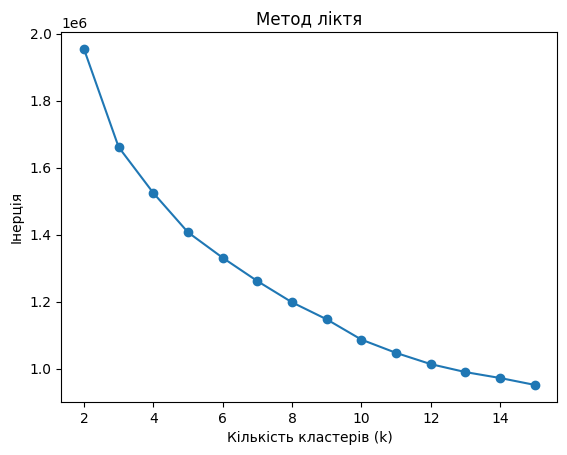

In [26]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
K = range(2, 16)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure()
plt.plot(K, inertia, marker='o')
plt.xlabel("Кількість кластерів (k)")
plt.ylabel("Інерція")
plt.title("Метод ліктя")
plt.show()

Було побудовано моделі K-Means для різних значень k (від 2 до 15). Для кожного значення обчислено інерцію — суму квадратів відстаней точок до центрів кластерів. На основі отриманих даних побудовано графік залежності інерції від кількості кластерів. Оптимальним обрано k = 4, оскільки при цьому значенні спостерігається точка перегину графіка. Після k = 4 зменшення інерції стає менш суттєвим, що свідчить про доцільність вибору саме цього значення.

In [27]:
from sklearn.cluster import KMeans

k_opt = 4
kmeans = KMeans(n_clusters=k_opt, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

print("Кількість треків у кожному кластері:")
(df['cluster'].value_counts(normalize=True)
 .sort_index()
 .mul(100)
 .round(2)
 .to_frame(name='percent'))

Кількість треків у кожному кластері:


,percent
cluster,
0,30.91
1,4.40
2,44.14
3,20.55


Було виконано кластеризацію даних за допомогою алгоритму K-Means із k = 4. Кожному треку було присвоєно мітку кластера, яку додано до таблиці як нову колонку. Визначено кількість об’єктів у кожному кластері, а також їх відносну частку. Найбільшу частку займає кластер 2 (~44.14%), що свідчить про наявність великої групи схожих треків. Кластер 0 також є значним (~30.91%), тоді як кластер 3 становить близько 20.55%. Найменшу частку має кластер 1 (~4.40%), що може вказувати на наявність менш поширеного типу музичних композицій. Отримані результати свідчать про нерівномірний розподіл даних між кластерами.

In [28]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]

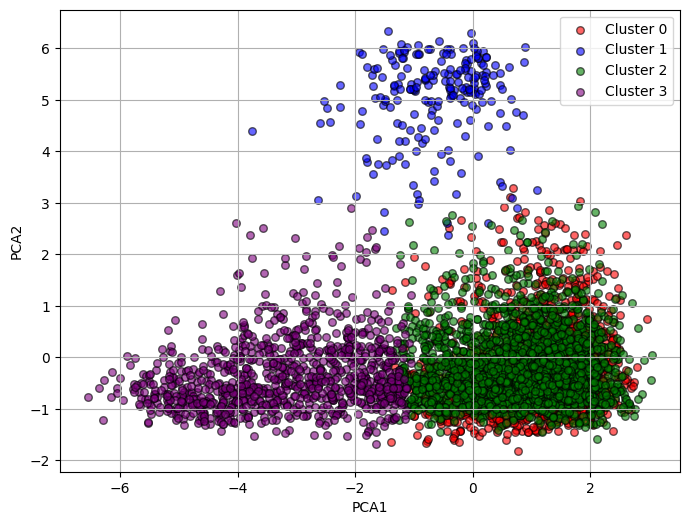

In [29]:
df_sample = df.sample(5000, random_state=42)  # беремо 5000 точок

plt.figure(figsize=(8,6))

colors = ['red', 'blue', 'green', 'purple']

for i, cluster in enumerate(sorted(df_sample['cluster'].unique())):
    subset = df_sample[df_sample['cluster'] == cluster]
    
    plt.scatter(
        subset['PCA1'],
        subset['PCA2'],
        color=colors[i],
        label=f'Cluster {cluster}',
        alpha=0.6,
        edgecolors='k',
        s=30
    )

plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.legend()
plt.grid(True)

plt.show()

Для зменшення розмірності даних було застосовано метод головних компонент (PCA) до двох компонент. З метою покращення читабельності використано випадкову вибірку даних. Побудовано двовимірний графік, на якому кожна точка відповідає окремому треку, а колір визначає кластер. З графіка видно, що деякі кластери добре відокремлені (наприклад, кластер 1), тоді як інші частково перекриваються (кластери 0 та 2). Це пояснюється зменшенням розмірності даних до двох компонент. Отримана візуалізація дозволяє оцінити структуру даних та взаємне розташування кластерів.

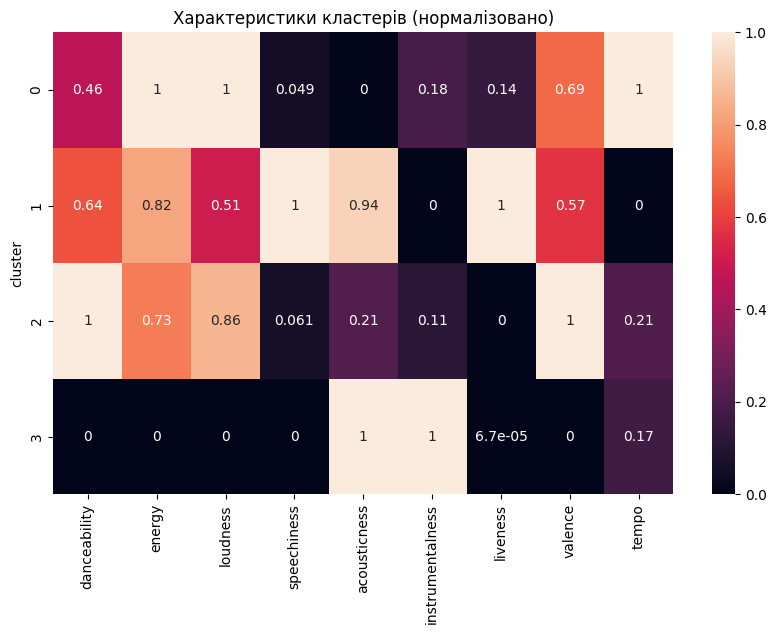

In [30]:
cluster_analysis = df.groupby('cluster')[[
    'danceability', 'energy', 'loudness', 'speechiness',
    'acousticness', 'instrumentalness', 'liveness',
    'valence', 'tempo'
]].mean()

cluster_norm = (cluster_analysis - cluster_analysis.min()) / (cluster_analysis.max() - cluster_analysis.min())

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(cluster_norm, annot=True)

plt.title("Характеристики кластерів (нормалізовано)")
plt.show()

Для аналізу кластерів було обчислено середні значення основних ознак та виконано їх нормалізацію для коректного порівняння.
На основі теплової карти можна зробити наступні висновки:
- Кластер 0 — характеризується високою енергією, гучністю та темпом, що відповідає динамічним та енергійним трекам.
- Кластер 1 — має високі значення acousticness, speechiness та liveness, що свідчить про більш спокійні або “живі” композиції (можливо, розмовні або акустичні).
- Кластер 2 — відзначається високою танцювальністю (danceability), гучністю та позитивною валентністю, що характерно для популярних танцювальних треків.
- Кластер 3 — має високі значення acousticness та instrumentalness і низькі значення енергії, що відповідає спокійним інструментальним композиціям.
Таким чином, кластеризація дозволила виділити різні типи музичних треків за їх аудіо-характеристиками.

Висновко: У ході роботи було виконано кластеризацію музичних треків за їх аудіо-характеристиками з використанням методу KMeans. Оптимальну кількість кластерів визначено за допомогою методу ліктя. Після зменшення розмірності даних методом PCA було проведено візуалізацію кластерів, що дозволило оцінити їх структуру та взаємне розташування. Аналіз середніх значень ознак показав, що кожен кластер відповідає певному типу треків (енергійні, танцювальні, акустичні, інструментальні). Таким чином, кластеризація дозволила ефективно згрупувати треки за схожими характеристиками.